# Procesamiento y clasificación de datos
# Clase 3

In [ ]:
!pip install transformers -q

In [ ]:
from transformers import pipeline

In [ ]:
emotionModel = pipeline('text-classification', model='SamLowe/roberta-base-go_emotions')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

In [ ]:
label = emotionModel(["Hello, I'm not feeling fine", 'Today is a great day'])
label

[{'label': 'neutral', 'score': 0.7501612901687622},
 {'label': 'joy', 'score': 0.6275294423103333}]

In [ ]:
def get_emotion(text):
    return(emotionModel(text)[0]['label'])

In [ ]:
get_emotion('This is hard')

'neutral'

# Vectorización

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/mohitgupta-omg/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv', encoding='latin-1')
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [ ]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)
df.columns = ['label', 'text']
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


<Axes: xlabel='label'>

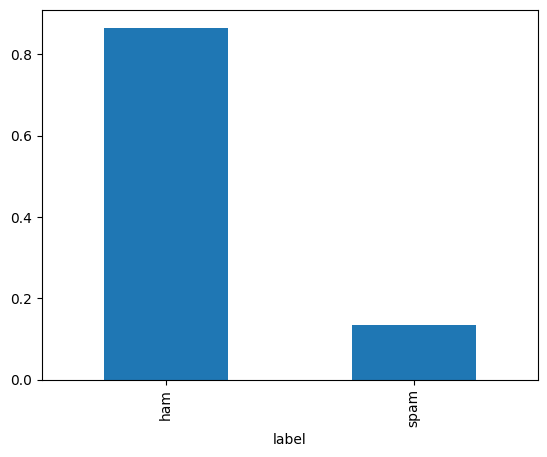

In [ ]:
df['label'].value_counts(normalize = True).plot.bar()

## Conteo de palabras

In [ ]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
display(df.head())

print(
    'ham',
    df[df['label'] == 'ham']['word_count'].describe()
)
print(
    'spam',
    df[df['label'] == 'spam']['word_count'].describe()
)

,label,text,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",20
1,ham,Ok lar... Joking wif u oni...,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28
3,ham,U dun say so early hor... U c already then say...,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",13


ham count    4825.000000
mean       14.200622
std        11.424511
min         1.000000
25%         7.000000
50%        11.000000
75%        19.000000
max       171.000000
Name: word_count, dtype: float64
spam count    747.000000
mean      23.851406
std        5.811898
min        2.000000
25%       22.000000
50%       25.000000
75%       28.000000
max       35.000000
Name: word_count, dtype: float64


## Conteo de caracteres

In [ ]:
df['char_count'] = df['text'].apply(lambda x: len(str(x)))
print(
    'ham',
    df[df['label'] == 'ham']['char_count'].describe()
)
print(
    'spam',
    df[df['label'] == 'spam']['char_count'].describe()
)

ham count    4825.000000
mean       71.023627
std        58.016023
min         2.000000
25%        33.000000
50%        52.000000
75%        92.000000
max       910.000000
Name: char_count, dtype: float64
spam count    747.000000
mean     138.866131
std       29.183082
min       13.000000
25%      132.500000
50%      149.000000
75%      157.000000
max      224.000000
Name: char_count, dtype: float64


## Densidad de palabras

In [ ]:
df['word_density'] = df['char_count'] / df['word_count']
df.head()

,label,text,word_count,char_count,word_density
0,ham,"Go until jurong point, crazy.. Available only ...",20,111,5.550000
1,ham,Ok lar... Joking wif u oni...,6,29,4.833333
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,155,5.535714
3,ham,U dun say so early hor... U c already then say...,11,49,4.454545
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,61,4.692308


## Representación gráfica

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df_ham = df[df['label'] == 'ham']
df_spam = df[df['label'] == 'spam']

In [ ]:
df_ham

,label,text,word_count,char_count,word_density
0,ham,"Go until jurong point, crazy.. Available only ...",20,111,5.550000
1,ham,Ok lar... Joking wif u oni...,6,29,4.833333
3,ham,U dun say so early hor... U c already then say...,11,49,4.454545
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,61,4.692308
6,ham,Even my brother is not like to speak with me. ...,16,77,4.812500
...,...,...,...,...,...
5565,ham,Huh y lei...,3,12,4.000000
5568,ham,Will Ì_ b going to esplanade fr home?,8,37,4.625000
5569,ham,"Pity, * was in mood for that. So...any other s...",10,57,5.700000
5570,ham,The guy did some bitching but I acted like i'd...,26,125,4.807692


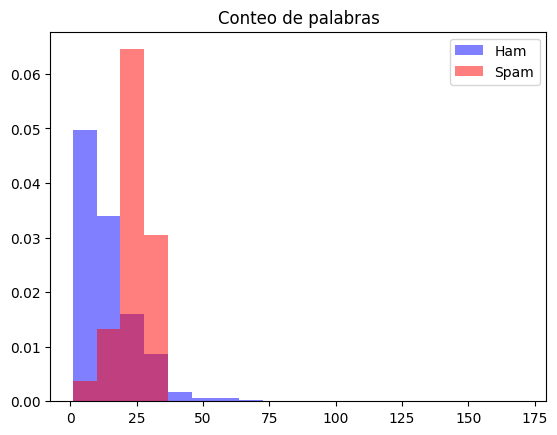

In [ ]:
plt.figure()
plt.title('Conteo de palabras')
bins = np.linspace(np.min(df['word_count']), np.max(df['word_count']), 20)

plt.hist(df_ham['word_count'],  label = 'Ham', bins = bins, color = 'blue', alpha = 0.5, density = True)
plt.hist(df_spam['word_count'],  label = 'Spam', bins = bins, color = 'red', alpha = 0.5, density = True)
plt.legend()
plt.show()



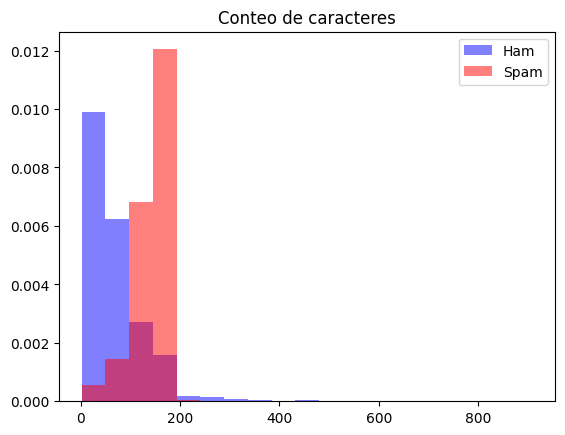

In [ ]:
plt.figure()
plt.title('Conteo de caracteres')
bins = np.linspace(np.min(df['char_count']), np.max(df['char_count']), 20)

plt.hist(df_ham['char_count'],  label = 'Ham', bins = bins, color = 'blue', alpha = 0.5, density = True)
plt.hist(df_spam['char_count'],  label = 'Spam', bins = bins, color = 'red', alpha = 0.5, density = True)
plt.legend()
plt.show()

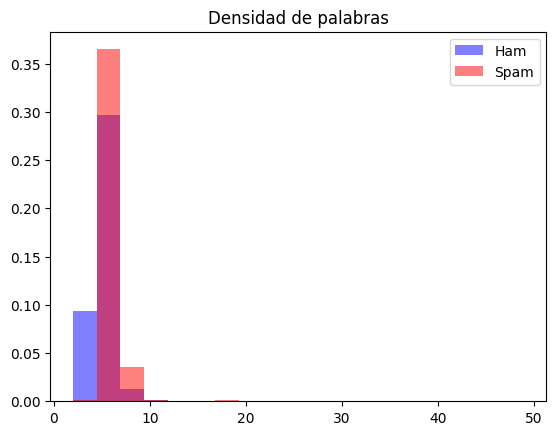

In [ ]:
plt.figure()
plt.title('Densidad de palabras')
bins = np.linspace(np.min(df['word_density']), np.max(df['word_density']), 20)

plt.hist(df_ham['word_density'],  label = 'Ham', bins = bins, color = 'blue', alpha = 0.5, density = True)
plt.hist(df_spam['word_density'],  label = 'Spam', bins = bins, color = 'red', alpha = 0.5, density = True)
plt.legend()
plt.show()

In [ ]:
import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [ ]:
text = list(df['text'])

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

corpus = []

In [ ]:
for i in range(len(text)):
    r = re.sub('[^a-zA-Z]', ' ', text[i])
    r = r.lower()
    r = r.split()
    r = [word for word in r if word not in stopwords.words('english')]
    r = [lemmatizer.lemmatize(word) for word in r]
    r = ' '.join(r)
    corpus.append(r)

In [ ]:
df['text_clean'] = corpus
df.head()

,label,text,word_count,char_count,word_density,text_clean
0,ham,"Go until jurong point, crazy.. Available only ...",20,111,5.550000,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,6,29,4.833333,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,155,5.535714,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,11,49,4.454545,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,61,4.692308,nah think go usf life around though


## Entrenamiento y prueba

In [ ]:
# Create Feature and Label sets
X = df['text_clean']
y = df['label']

# train test split (80% train - 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

# Si nos interesa empatar distribuciones, se puede hacer alguna metodología para ello 👍

print('Training Data :', X_train.size)
print('Testing Data : ', X_test.size)

Training Data : 4457
Testing Data :  1115


In [ ]:
X_train

,text_clean
1801,wanna watch movie
2878,u still painting ur wall
2949,said would woke
788,free top polyphonic tone call national rate ge...
4458,welcome uk mobile date msg free giving free ca...
...,...
5408,pub
556,lunch online
3977,reason team budget available last buy unsold p...
2527,mmmmm loved waking word morning miss love hope...


## Vectorización

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

Por ejemplo, `CountVectorizer` hace algo así:
# eso es to eso es to eso es todo amigos
# hola señorita


| | eso | es | to | todo | amigos | hola | señorita
| --- | --- | --- | --- | --- | --- | --- | ---
eso es to eso es to eso es todo amigos | 3 | 3 | 2 | 1 | 1 | 0 | 0
hola señorita | 0 | 0 | 0 | 0 | 0 | 1 | 1

In [ ]:
# conteo de palabras
count_vect = CountVectorizer(analyzer='word')
count_vect.fit(X_train)
xtrain_count =  count_vect.transform(X_train)
xtest_count =  count_vect.transform(X_test)

# palabras
tfidf_vect = TfidfVectorizer(analyzer='word')
xtrain_tfidf =  tfidf_vect.fit_transform(X_train)
xtest_tfidf =  tfidf_vect.transform(X_test)

# ngramas
tfidf_vect_ngram = TfidfVectorizer(analyzer='word', ngram_range=(2,3))
xtrain_tfidf_ngram =  tfidf_vect_ngram.fit_transform(X_train)
xtest_tfidf_ngram =  tfidf_vect_ngram.transform(X_test)

# caracteres
tfidf_vect_ngram_chars = TfidfVectorizer(analyzer='char')
xtrain_tfidf_ngram_chars =  tfidf_vect_ngram_chars.fit_transform(X_train)
xtest_tfidf_ngram_chars =  tfidf_vect_ngram_chars.transform(X_test)

In [ ]:
# Devuelve las palabras únicas en orden alfabético
count_vect.get_feature_names_out()

array(['aa', 'aaniye', 'aaooooright', ..., 'zoom', 'zouk', 'zyada'],
      dtype=object)

In [ ]:
# Devuelve listas por cada oración con presencia (1)/ausencia (0) de las palabras
xtrain_count.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

## Modelos

In [ ]:
from sklearn.linear_model import LogisticRegression

import pandas as pd
from sklearn import metrics

In [ ]:
lr = LogisticRegression()
lr.fit(xtrain_count, y_train)

# generate predictions
predictions = lr.predict(xtest_count)

In [ ]:
df_confusion = pd.DataFrame(metrics.confusion_matrix(y_test, predictions), index=['ham','spam'], columns=['ham_pred','spam_pred'])
df_confusion

,ham_pred,spam_pred
ham,967,6
spam,16,126


In [ ]:
pares = [
    ('conteo', xtrain_count, xtest_count),
    ('palabras', xtrain_tfidf, xtest_tfidf),
    ('ngramas', xtrain_tfidf_ngram, xtest_tfidf_ngram),
    ('caracteres', xtrain_tfidf_ngram_chars, xtest_tfidf_ngram_chars)
]

for datos in pares:
    lr.fit(datos[1], y_train)
    predictions = lr.predict(datos[2])
    df_confusion = pd.DataFrame(metrics.confusion_matrix(y_test, predictions), index=['ham','spam'], columns=['ham','spam'])
    print(datos[0], '\n', df_confusion, '\n')

conteo 
       ham  spam
ham   967     6
spam   16   126 

palabras 
       ham  spam
ham   971     2
spam   35   107 

ngramas 
       ham  spam
ham   973     0
spam  114    28 

caracteres 
       ham  spam
ham   952    21
spam   75    67 



- [ ] SentenceTransformer

## Tarea (10 puntos)

- Hacer diseño de experimentos para comparar modelos y sus hiperparámetros con relación a la clasificación de textos
- Escribir un reporte con los hallazgos, metodología y resultados en PDF, markdown, word, etc y subirlo en una sección claramente identificable de tu repositorio.

## Referencias

- https://www.datacamp.com/tutorial/text-classification-python
- https://www.analyticsvidhya.com/blog/2018/04/a-comprehensive-guide-to-understand-and-implement-text-classification-in-python/
- https://medium.com/analytics-vidhya/nlp-tutorial-for-text-classification-in-python-8f19cd17b49e
- https://reintech.io/blog/how-to-create-a-text-classification-model-with-python
- https://realpython.com/python-keras-text-classification/